# Day3：从 bigram 统计到可训练的字符语言模型

思路：把名字数据缩小成一个最小字符语言模型：给定当前字符，只预测下一个字符。前半段用计数直接得到概率，后半段把同一张转移表改写成 one-hot 乘 W 再接 softmax，并用 NLL、autograd、L2 正则和梯度下降训练它——从简单的数学推导到一个真正真正的“模型”。

In [1]:
# 阶段 1：读取数据。names.txt 与本 notebook 放在同一目录，因此这里使用相对路径。
# 每行是一个英文名字；splitlines() 把文本拆成 list[str]，后面每个名字会贡献若干个字符转移。
words = open('names.txt', 'r', encoding='utf-8').read().splitlines()


In [2]:
# 先查看前 10 个样本，确认文件按“每行一个名字”的格式读入。
words[:10]


['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn']

In [3]:
len(words)

32033

In [4]:
# 观察名字长度范围；长度为 L 的名字加上起止边界后会产生 L + 1 个 bigram。
min(len(w) for w in words)

2

In [5]:
# 最长名字长度；这个统计帮助我们估算每个名字可能产生的转移数量。
max(len(w) for w in words)

15

## 阶段 2：统计字符 bigram

一个长度为 L 的名字会贡献 L + 1 个相邻字符转移。开始和结束边界让模型同时学习名字从哪里开始、何时停止。


In [6]:
# 阶段 2：先用 Python 字典统计字符 bigram。
# bigram 只看相邻两个字符；<S> 是开始标记，<E> 是结束标记。
# 例如 emma -> <S>, e, m, m, a, <E>，会贡献 5 个转移。
b = {}
for w in words:
    chs = ['<S>'] + list(w) + ['<E>']
    for ch1, ch2 in zip(chs, chs[1:]):
        bigram = (ch1, ch2)
        b[bigram] = b.get(bigram, 0) + 1


In [7]:
# 按出现次数从高到低查看转移，先观察数据中的局部字符规律。
# 这里的数字是计数，不是概率；同一个前字符对应的所有后字符计数还要再归一化。
sorted(b.items(), key=lambda x: -x[1])


[(('n', '<E>'), 6763),
 (('a', '<E>'), 6640),
 (('a', 'n'), 5438),
 (('<S>', 'a'), 4410),
 (('e', '<E>'), 3983),
 (('a', 'r'), 3264),
 (('e', 'l'), 3248),
 (('r', 'i'), 3033),
 (('n', 'a'), 2977),
 (('<S>', 'k'), 2963),
 (('l', 'e'), 2921),
 (('e', 'n'), 2675),
 (('l', 'a'), 2623),
 (('m', 'a'), 2590),
 (('<S>', 'm'), 2538),
 (('a', 'l'), 2528),
 (('i', '<E>'), 2489),
 (('l', 'i'), 2480),
 (('i', 'a'), 2445),
 (('<S>', 'j'), 2422),
 (('o', 'n'), 2411),
 (('h', '<E>'), 2409),
 (('r', 'a'), 2356),
 (('a', 'h'), 2332),
 (('h', 'a'), 2244),
 (('y', 'a'), 2143),
 (('i', 'n'), 2126),
 (('<S>', 's'), 2055),
 (('a', 'y'), 2050),
 (('y', '<E>'), 2007),
 (('e', 'r'), 1958),
 (('n', 'n'), 1906),
 (('y', 'n'), 1826),
 (('k', 'a'), 1731),
 (('n', 'i'), 1725),
 (('r', 'e'), 1697),
 (('<S>', 'd'), 1690),
 (('i', 'e'), 1653),
 (('a', 'i'), 1650),
 (('<S>', 'r'), 1639),
 (('a', 'm'), 1634),
 (('l', 'y'), 1588),
 (('<S>', 'l'), 1572),
 (('<S>', 'c'), 1542),
 (('<S>', 'e'), 1531),
 (('j', 'a'), 1473),
 (

## 阶段 3：从字典到矩阵

N[i, j] 是当前字符 i 到下一个字符 j 的计数。矩阵形式让后续的归一化、批量计算和矩阵乘法成为可能。


In [8]:
# 阶段 3：把字典统计改写为 PyTorch Tensor，后续才能使用矩阵运算和 autograd。
import torch


In [9]:
# N[i, j] 记录字符 i 后面出现字符 j 的次数。
# 26 个小写字母 + 1 个边界符号 . = 27 个类别，因此 N.shape == (27, 27)。
N = torch.zeros((27, 27), dtype=torch.int32)


In [10]:
# 建立双向词表：stoi 把字符映射到整数，itos 把整数映射回字符。
# 矩阵版本用同一个 . 同时表示名字开始和结束：第 0 行主要表示起始转移，第 0 列主要表示结束转移。
chars = sorted(list(set(''.join(words))))
stoi = {s: i + 1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i: s for s, i in stoi.items()}


In [11]:
# 把每个名字的相邻字符映射为矩阵坐标并累加。
# 当前字符是行索引 ix1，下一个字符是列索引 ix2。
for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        N[ix1, ix2] += 1


In [12]:
# 可视化 27×27 的 bigram 计数矩阵。
# 纵轴是当前字符，横轴是下一个字符；颜色越深表示该转移出现得越多。
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Arial Unicode MS', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False
%matplotlib inline

plt.figure(figsize=(16, 16))
plt.imshow(N, cmap='Blues')
for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha='center', va='bottom', color='gray')
        plt.text(j, i, N[i, j].item(), ha='center', va='top', color='gray')
plt.title('字符 Bigram 计数矩阵：行是当前字符，列是下一个字符')
plt.axis('off')


(np.float64(-0.5), np.float64(26.5), np.float64(26.5), np.float64(-0.5))

In [13]:
# 查看从开始状态 . 出发的所有首字符计数；第 0 行表示起始转移。
N[0]


tensor([   0, 4410, 1306, 1542, 1690, 1531,  417,  669,  874,  591, 2422, 2963,
        1572, 2538, 1146,  394,  515,   92, 1639, 2055, 1308,   78,  376,  307,
         134,  535,  929], dtype=torch.int32)

In [14]:
# 把首字符计数除以总数，得到 P(next | start)。
# p.shape == [27]，p.sum() == 1；第 0 项对应再次采到边界符号。
p = N[0].float()
p = p / p.sum()
p


tensor([0.0000, 0.1377, 0.0408, 0.0481, 0.0528, 0.0478, 0.0130, 0.0209, 0.0273,
        0.0184, 0.0756, 0.0925, 0.0491, 0.0792, 0.0358, 0.0123, 0.0161, 0.0029,
        0.0512, 0.0642, 0.0408, 0.0024, 0.0117, 0.0096, 0.0042, 0.0167, 0.0290])

In [15]:
# 固定随机种子，按首字符概率采样一次。
# 固定种子只保证同一段调用顺序可复现，不代表换一套概率分布后仍会得到相同字符串。
g = torch.Generator().manual_seed(2147483647)
ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
ix
itos[ix]


'c'

In [16]:
# 先用 3 类分布做一个最小例子，理解 multinomial 的输入格式。
# 输入只需是非负权重；这里先归一化成概率，便于直接解释。
g = torch.Generator().manual_seed(2147483647)
p = torch.rand(3, generator=g)
p = p / p.sum()
p


tensor([0.6064, 0.3033, 0.0903])

In [17]:
# replacement=True 表示有放回采样：每次抽完后仍可再次抽到同一类别。
torch.multinomial(p, num_samples=100, replacement=True, generator=g)


tensor([1, 1, 2, 0, 0, 2, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 2, 0, 0,
        1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1,
        0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
        0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 2, 0, 1, 0,
        0, 1, 1, 1])

In [18]:
# multinomial 接收的一维概率向量形状是 [类别数]。
p.shape


torch.Size([3])

## 阶段 4：条件概率、平滑与采样

每一行归一化后就是给定当前字符时的下一个字符概率。加一平滑为未见过转移留下非零概率，multinomial 按该分布抽取字符。


In [19]:
# 加一平滑：给每个可能的 bigram 先加一个伪计数，避免未见过的转移得到概率 0。
# N.shape == [27, 27]；按 dim=1 求和后保留维度，分母形状是 [27, 1]。
# [27, 27] / [27, 1] 会沿列方向广播：每一行除以自己的行和。
# 不要去掉 keepdim=True：得到 [27] 后，方阵虽然可能仍能运行，但广播语义会从最后一维对齐，容易把行统计量错配到列。
P = (N + 1).float()
P = P / P.sum(1, keepdim=True)


In [20]:
# 检查每一行是否都是概率分布；这里检查第 0 行，正确结果应为 1。
P[0].sum()


tensor(1.)

In [21]:
# 阶段 4：用完整的平滑矩阵逐字符生成名字。
# 当前 ix 是上一个字符；P[ix] 是下一个字符的条件概率向量。采到 0 就遇到结束边界。
g = torch.Generator().manual_seed(2147483647)
for i in range(5):
    out = []
    ix = 0
    while True:
        p = P[ix]
        ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        out.append(itos[ix])
        if ix == 0:
            break
    print(''.join(out))


cexze.
momasurailezitynn.
konimittain.
llayn.
ka.


## 阶段 5：用 NLL 评价概率模型

名字概率是每一步条件概率的连乘。取对数把连乘变成求和，取负号后就是训练中常见的平均负对数似然。


In [22]:
# 阶段 5：用真实数据评价这个概率模型。
# 目标是让真实 bigram 的条件概率尽可能大：最大化总 log-likelihood。
# 实际训练通常改写成最小化平均负对数似然（NLL），这里先用循环把定义展开。
total_log_likelihood = 0.0
num_bigrams = 0
for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        prob = P[ix1, ix2]
        logprob = torch.log(prob)
        total_log_likelihood += logprob
        num_bigrams += 1
        # print(f'{ch1}{ch2}: {prob:.4f} {logprob:.4f}')

print(f'{total_log_likelihood=}')
nll = -total_log_likelihood
print(f'{nll=}')
print(f'{nll / num_bigrams}')


total_log_likelihood=tensor(-559951.5625)
nll=tensor(559951.5625)
2.4543561935424805


## 阶段 6：把统计表改写成神经网络

one-hot 输入只会选中 W 的一行，所以 one-hot 乘 W 本质上仍是在查一张字符转移表；区别是每个表项从计数变成了可学习的 logit。


In [23]:
# 阶段 6：只用第一个名字构造一个 5 条样本的教学 batch。
# emma -> .e, em, mm, ma, a.；xs 是当前字符，ys 是真实的下一个字符。
# 这只是为了逐样本观察 forward/loss/backward，不是最终训练集。
xs, ys = [], []
for w in words[:1]:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        xs.append(ix1)
        ys.append(ix2)

# torch.tensor(data) 根据 Python list 创建 Tensor；这里显式指定 long，满足 one_hot 的整数索引要求。
# torch.Tensor(data) 是历史上的类构造写法，默认 dtype 行为不如 torch.tensor 清晰，实际代码优先使用后者。
xs = torch.tensor(xs, dtype=torch.long)
ys = torch.tensor(ys, dtype=torch.long)


In [24]:
# 输入字符索引，shape == [5]。
xs


tensor([ 0,  5, 13, 13,  1])

In [25]:
# 目标字符索引，shape == [5]；xs[i] 和 ys[i] 组成一个监督样本。
ys


tensor([ 5, 13, 13,  1,  0])

In [26]:
# one-hot 编码：5 个样本、每个样本 27 个类别，因此 xenc.shape == [5, 27]。
# one-hot 本身是整数/布尔结构，转 float 后才能与浮点权重矩阵做矩阵乘法。
import torch.nn.functional as F
xenc = F.one_hot(xs, num_classes=27).float()
xenc


tensor([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.]])

In [27]:
# 初始化教学用权重矩阵 W。W[i, j] 表示当前字符 i 选择下一个字符 j 的未归一化分数。
# requires_grad=True 是 loss.backward() 能工作的前提；W.grad = None 只能清空梯度，不能开启自动微分。
g = torch.Generator().manual_seed(2147483647)
W = torch.rand((27, 27), generator=g, requires_grad=True)
print(f'{W.shape=}, {W.requires_grad=}')


W.shape=torch.Size([27, 27]), W.requires_grad=True


In [28]:
# 教学版 forward：one-hot × W 得到 logits，再通过 exp 和逐行归一化得到概率。
# xenc.shape [5,27] @ W.shape [27,27] -> logits.shape [5,27]。
# one-hot 只有一个 1，所以每个样本实际上选出了 W 中对应当前字符的一行。
# counts 是模型生成的正值权重，不等于原始统计矩阵 N；只有在 logits 恰好等于 log 计数时才有对应关系。
logits = xenc @ W
counts = logits.exp()
probs = counts / counts.sum(1, keepdim=True)
probs


tensor([[0.0426, 0.0299, 0.0233, 0.0382, 0.0229, 0.0229, 0.0507, 0.0563, 0.0211,
         0.0280, 0.0440, 0.0313, 0.0497, 0.0439, 0.0308, 0.0261, 0.0424, 0.0563,
         0.0547, 0.0325, 0.0425, 0.0222, 0.0472, 0.0285, 0.0566, 0.0295, 0.0258],
        [0.0298, 0.0278, 0.0241, 0.0308, 0.0300, 0.0362, 0.0401, 0.0269, 0.0538,
         0.0445, 0.0560, 0.0239, 0.0358, 0.0258, 0.0370, 0.0542, 0.0275, 0.0513,
         0.0263, 0.0253, 0.0315, 0.0294, 0.0317, 0.0507, 0.0554, 0.0562, 0.0380],
        [0.0317, 0.0341, 0.0391, 0.0342, 0.0347, 0.0217, 0.0243, 0.0281, 0.0464,
         0.0537, 0.0481, 0.0261, 0.0520, 0.0339, 0.0449, 0.0443, 0.0228, 0.0305,
         0.0345, 0.0543, 0.0219, 0.0490, 0.0287, 0.0234, 0.0548, 0.0312, 0.0516],
        [0.0317, 0.0341, 0.0391, 0.0342, 0.0347, 0.0217, 0.0243, 0.0281, 0.0464,
         0.0537, 0.0481, 0.0261, 0.0520, 0.0339, 0.0449, 0.0443, 0.0228, 0.0305,
         0.0345, 0.0543, 0.0219, 0.0490, 0.0287, 0.0234, 0.0548, 0.0312, 0.0516],
        [0.0402, 0.0517,

In [29]:
# 逐样本拆解 NLL，观察“真实下一个字符的概率”如何进入 loss。
nlls = torch.zeros(xs.numel())
for i in range(xs.numel()):
    x = xs[i].item()  # 当前字符的整数索引
    y = ys[i].item()  # 真实下一个字符的整数索引
    print('-------')
    print(f'第 {i + 1} 个 bigram：{itos[x]}{itos[y]}（索引 {x}, {y}）')
    print('输入字符索引：', x)
    print('模型输出的 27 类概率：', probs[i])
    print('真实目标索引：', y)
    p_true = probs[i, y]
    print('真实下一个字符的概率：', p_true.item())
    logp = torch.log(p_true)
    print('log probability：', logp.item())
    nll = -logp
    print('negative log likelihood：', nll.item())
    nlls[i] = nll

print('=====')
print('平均 NLL =', nlls.mean().item())


-------
第 1 个 bigram：.e（索引 0, 5）
输入字符索引： 0
模型输出的 27 类概率： tensor([0.0426, 0.0299, 0.0233, 0.0382, 0.0229, 0.0229, 0.0507, 0.0563, 0.0211,
        0.0280, 0.0440, 0.0313, 0.0497, 0.0439, 0.0308, 0.0261, 0.0424, 0.0563,
        0.0547, 0.0325, 0.0425, 0.0222, 0.0472, 0.0285, 0.0566, 0.0295, 0.0258],
       grad_fn=<SelectBackward0>)
真实目标索引： 5
真实下一个字符的概率： 0.022935139015316963
log probability： -3.775084972381592
negative log likelihood： 3.775084972381592
-------
第 2 个 bigram：em（索引 5, 13）
输入字符索引： 5
模型输出的 27 类概率： tensor([0.0298, 0.0278, 0.0241, 0.0308, 0.0300, 0.0362, 0.0401, 0.0269, 0.0538,
        0.0445, 0.0560, 0.0239, 0.0358, 0.0258, 0.0370, 0.0542, 0.0275, 0.0513,
        0.0263, 0.0253, 0.0315, 0.0294, 0.0317, 0.0507, 0.0554, 0.0562, 0.0380],
       grad_fn=<SelectBackward0>)
真实目标索引： 13
真实下一个字符的概率： 0.025837397202849388
log probability： -3.6559324264526367
negative log likelihood： 3.6559324264526367
-------
第 3 个 bigram：mm（索引 13, 13）
输入字符索引： 13
模型输出的 27 类概率： tensor([0.0317, 0.0341, 0.03

In [30]:
# 用高级索引一次取出每个样本对应的真实类别概率，再求平均 NLL。
# probs[torch.arange(5), ys] 的 shape 是 [5]，每个位置只保留一个正确答案概率。
loss = -probs[torch.arange(xs.numel()), ys].log().mean()
loss


tensor(3.4815, grad_fn=<NegBackward0>)

In [31]:
# 反向传播：先清空旧梯度，再沿 loss -> probs -> counts -> logits -> W 的计算图反传。
# PyTorch 默认累加梯度，所以每次 backward 前都要把 W.grad 设回 None。
# 如果 W 没有 requires_grad=True，loss 会没有 grad_fn，并触发“does not require grad”报错。
W.grad = None
loss.backward()


In [32]:
# 查看教学 batch 的 loss；这次 loss 还没有加 L2 正则项。
print(loss.item())


3.4815192222595215


In [33]:
# 用一次最朴素的梯度下降更新 W。
# W.data 是课程里的简写；更安全的现代写法是放在 torch.no_grad() 中原地更新。
with torch.no_grad():
    W -= 0.1 * W.grad


## 阶段 7：全量训练

单个名字的 5 条样本只用于拆解计算图；真正训练时使用全部名字产生的字符转移，并用梯度下降调整 W。


In [34]:
# 阶段 7：回到完整数据集，所有名字的相邻字符对都作为训练样本。
# 总样本数 = 每个名字的长度 + 1 的总和；xs[i] 是当前字符，ys[i] 是下一个真实字符。
xs, ys = [], []
for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        xs.append(ix1)
        ys.append(ix2)
xs = torch.tensor(xs, dtype=torch.long)
ys = torch.tensor(ys, dtype=torch.long)
num = xs.nelement()
print('训练样本数：', num)

# W.shape == [27,27]：每一行是一个当前字符，每一列是一个候选下一个字符。
g = torch.Generator().manual_seed(2147483647)
W = torch.randn((27, 27), generator=g, requires_grad=True)


训练样本数： 228146


In [35]:
# W 的平方均值是 L2 正则项的核心：reg_strength * (W**2).mean()。
# 这里只观察正则项的未乘系数部分，不要把它误认为完整 loss。
(W ** 2).mean()


tensor(0.9665, grad_fn=<MeanBackward0>)

In [36]:
# 完整训练循环：每一轮依次执行 forward、计算目标、backward、更新参数。
# 目标 = 平均 NLL + L2 正则；加一平滑作用于计数/概率，L2 作用于 W，二者不等价。
# 这里保留 exp -> normalize 的展开写法，方便对应前面的概率模型；数值更稳的生产写法是 F.log_softmax 或 F.cross_entropy。
num_steps = 100
learning_rate = 50.0
reg_strength = 0.01
loss_history, nll_history, reg_history = [], [], []

for k in range(num_steps):
    # ① forward：把所有当前字符一次性 one-hot 化。xenc.shape == [num,27]。
    xenc = F.one_hot(xs, num_classes=27).float()
    logits = xenc @ W                              # [num,27]：每个样本对 27 个下一个字符的分数
    counts = logits.exp()                          # [num,27]：正值权重（教学展开，不是原始 N）
    probs = counts / counts.sum(1, keepdim=True)   # [num,27]：每一行归一化为条件概率

    # 高级索引逐行取出 probs[i, ys[i]]，只评价真实下一个字符的概率。
    nll = -probs[torch.arange(num), ys].log().mean()
    reg_loss = reg_strength * (W ** 2).mean()
    loss = nll + reg_loss
    loss_history.append(loss.item())
    nll_history.append(nll.item())
    reg_history.append(reg_loss.item())
    if k % 10 == 0 or k == num_steps - 1:
        print(f'第 {k:03d} 轮：total={loss.item():.6f}, nll={nll.item():.6f}, reg={reg_loss.item():.6f}')

    # ② backward：梯度默认累加，因此每轮先清零。
    W.grad = None
    loss.backward()

    # ③ update：沿负梯度方向移动；no_grad 防止更新操作再次进入计算图。
    with torch.no_grad():
        W -= learning_rate * W.grad


第 000 轮：total=3.768619, nll=3.758954, reg=0.009665


第 010 轮：total=2.696506, nll=2.688079, reg=0.008426


第 020 轮：total=2.582256, nll=2.572681, reg=0.009575


第 030 轮：total=2.541352, nll=2.530679, reg=0.010673


第 040 轮：total=2.521264, nll=2.509633, reg=0.011630


...

第 060 轮：total=2.502706, nll=2.489540, reg=0.013166


第 070 轮：total=2.497879, nll=2.484101, reg=0.013778


第 080 轮：total=2.494439, nll=2.480127, reg=0.014312


第 090 轮：total=2.491893, nll=2.477113, reg=0.014781


第 099 轮：total=2.490130, nll=2.474973, reg=0.015157


## 训练结果：总目标的组成

下面将总 loss、纯 NLL 和 L2 正则项分开画出来，避免把“拟合数据”和“约束权重”混成一个无法解释的数字。


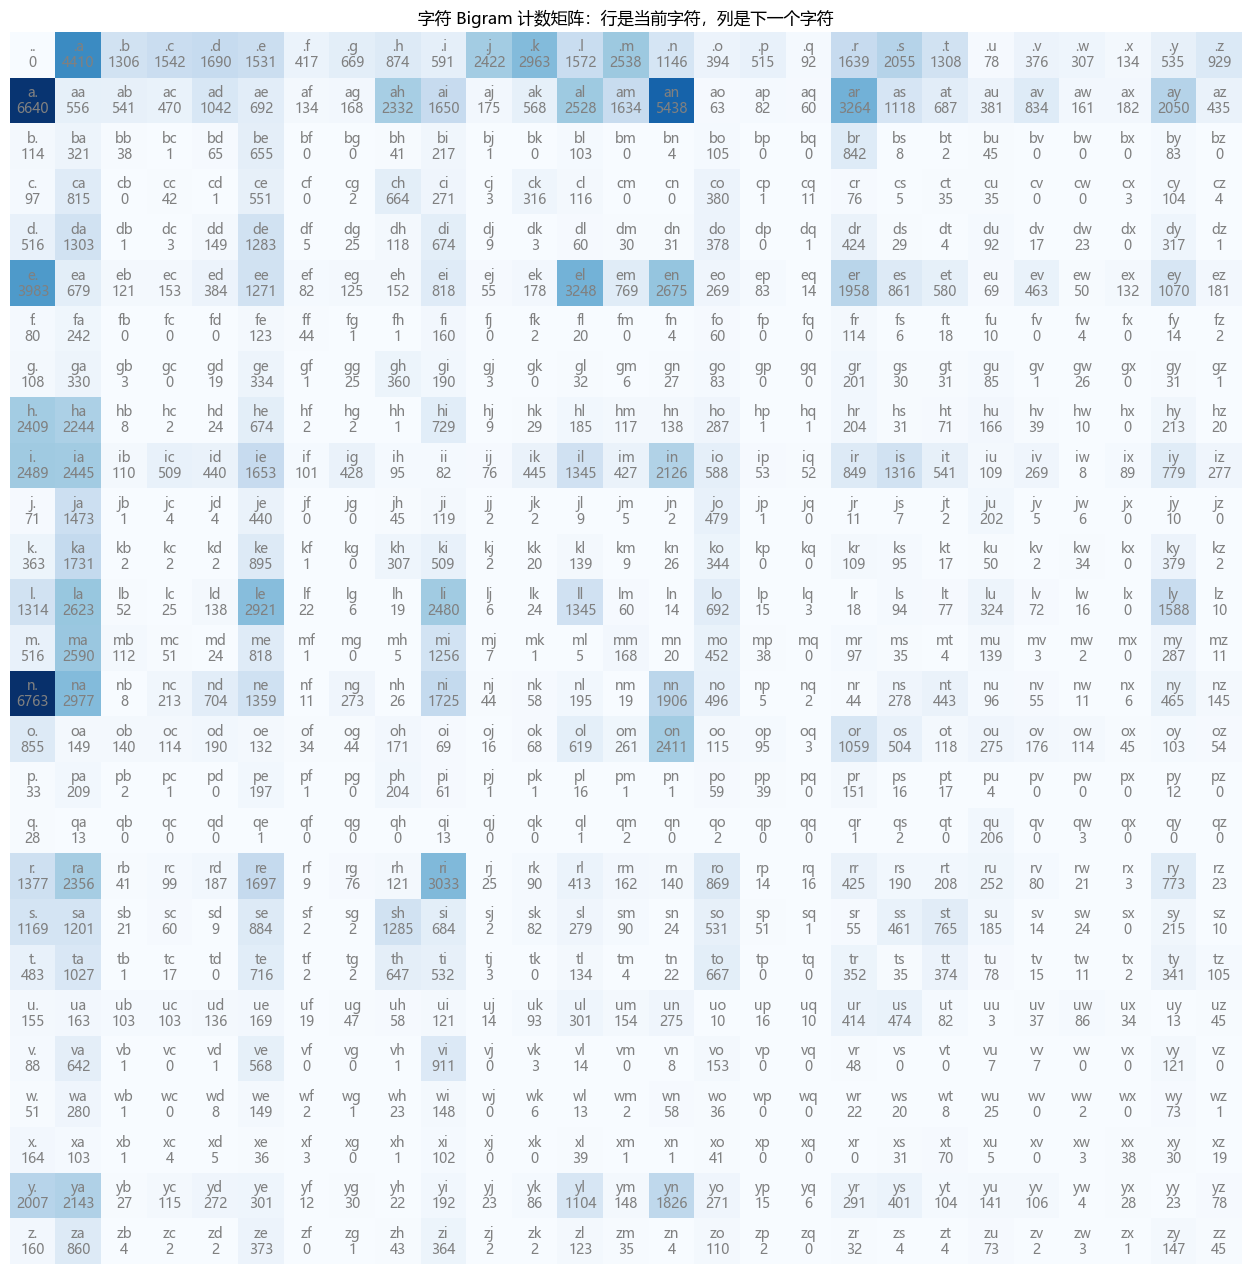

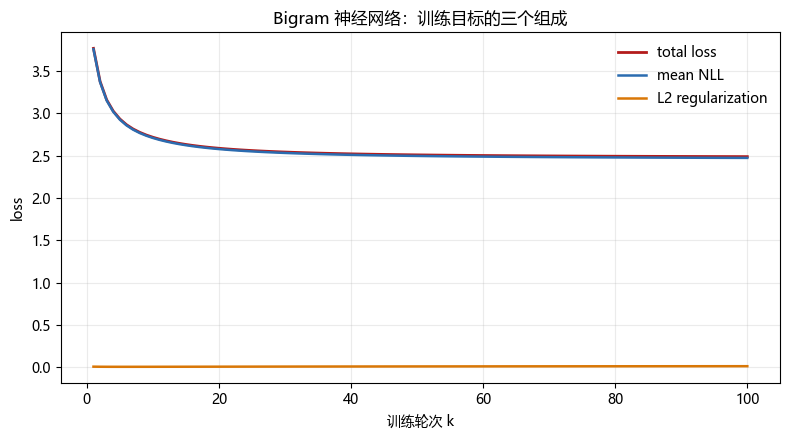

初始 total loss = 3.768619
最终 total loss = 2.490130


In [37]:
# 训练结果可视化：总目标 = 平均 NLL + L2 正则。
fig, ax = plt.subplots(figsize=(8, 4.5))
steps = range(1, len(loss_history) + 1)
ax.plot(steps, loss_history, label='total loss', color='#B31B1B', linewidth=2)
ax.plot(steps, nll_history, label='mean NLL', color='#2B6CB0', linewidth=1.8)
ax.plot(steps, reg_history, label='L2 regularization', color='#D97706', linewidth=1.8)
ax.set_xlabel('训练轮次 k')
ax.set_ylabel('loss')
ax.set_title('Bigram 神经网络：训练目标的三个组成')
ax.grid(alpha=0.25)
ax.legend(frameon=False)
fig.tight_layout()
plt.show()
print(f'初始 total loss = {loss_history[0]:.6f}')
print(f'最终 total loss = {loss_history[-1]:.6f}')


## 阶段 8：从训练后的参数采样

训练结束后，W 不再是随机表，而是一张经目标函数和梯度更新得到的可学习转移表。它能生成有名字外形的字符串，但仍然只看一个字符的局部上下文。


In [38]:
# 阶段 8：用训练后的 W 生成名字。
# 每一步都把当前字符 ix 编成 one-hot，再经过同一个 W 得到下一个字符分布。
# 与统计模型相比，二者的条件概率应接近，但由于参数化、正则化和随机采样不同，字符串不保证逐个相同。
g = torch.Generator().manual_seed(2147483647)
with torch.no_grad():
    for i in range(5):
        out = []
        ix = 0
        while True:
            xenc = F.one_hot(torch.tensor([ix]), num_classes=27).float()
            logits = xenc @ W
            counts = logits.exp()
            p = counts / counts.sum(1, keepdim=True)
            ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
            out.append(itos[ix])
            if ix == 0:
                break
        print(''.join(out))


cexze.
momasurailezityha.
konimittain.
llayn.
ka.
